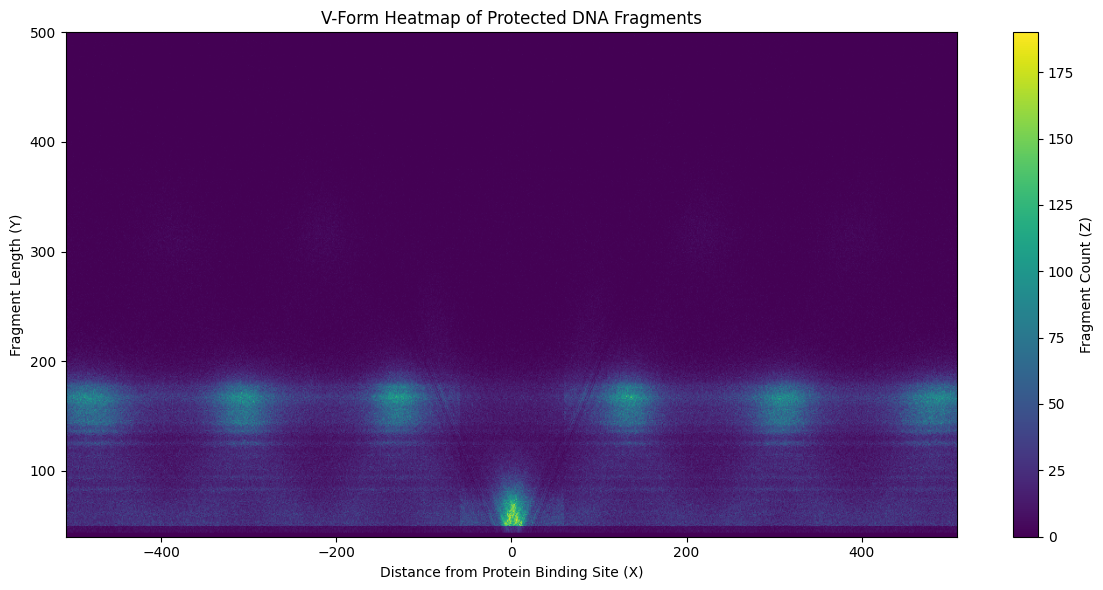

In [1]:
import gzip
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Step 1: Parse the file and calculate X and Y
heatmap_data = defaultdict(lambda: defaultdict(int))  # X -> Y -> count

with gzip.open("mapped.bed.gz", "rt") as f:
    for line in f:
        fields = line.strip().split('\t')
        if len(fields) < 11:
            continue  # Skip malformed lines

        try:
            # Compute centers
            c1_start, c1_end = int(fields[2]), int(fields[3])
            c2_start, c2_end = int(fields[8]), int(fields[9])
            c1 = (c1_start + c1_end) // 2
            c2 = (c2_start + c2_end) // 2

            # X and Y values
            x = c2 - c1
            y = c2_end - c2_start

            # Update count (Z)
            heatmap_data[x][y] += 1
        except ValueError:
            continue  # Skip lines with conversion errors

# Step 2: Convert to matrix form for plotting
x_vals = sorted(heatmap_data.keys())
y_vals = sorted({y for x in heatmap_data for y in heatmap_data[x]})

x_idx = {x: i for i, x in enumerate(x_vals)}
y_idx = {y: i for i, y in enumerate(y_vals)}

matrix = np.zeros((len(y_vals), len(x_vals)))

for x in x_vals:
    for y in heatmap_data[x]:
        matrix[y_idx[y], x_idx[x]] = heatmap_data[x][y]

# Step 3: Plot heatmap
plt.figure(figsize=(12, 6))
plt.imshow(matrix, aspect='auto', origin='lower', cmap='viridis',
           extent=[min(x_vals), max(x_vals), min(y_vals), max(y_vals)])
plt.colorbar(label="Fragment Count (Z)")
plt.xlabel("Distance from Protein Binding Site (X)")
plt.ylabel("Fragment Length (Y)")
plt.title("V-Form Heatmap of Protected DNA Fragments")
plt.tight_layout()
plt.show()
